# Stationary Captures: Statistical Analysis

Use this notebook to review results from the stationary captures, compare the resulting histograms directly, and compute statistics to inform calibration decisions.

## Setup

In [ ]:
from signal_utils import IMUSampleReader

import matplotlib.pyplot as plt
import numpy as np
import math

G = 9.80665

reader = IMUSampleReader()

sixFaceStationaryCaptures = [
    "../0-capture/stationary/may-2026/pos-x-up.csv",
    "../0-capture/stationary/may-2026/neg-x-up.csv",
    "../0-capture/stationary/may-2026/pos-y-up.csv",
    "../0-capture/stationary/may-2026/neg-y-up.csv",
    "../0-capture/stationary/may-2026/pos-z-up.csv",
    "../0-capture/stationary/may-2026/neg-z-up.csv",
]
tiltedStationaryCaptures = [
    "../0-capture/stationary/jul-30-2026-dlpf-disabled/pos-x-pos-z-tilt.csv",
    "../0-capture/stationary/jul-30-2026-dlpf-disabled/neg-x-pos-z-tilt.csv",
    "../0-capture/stationary/jul-30-2026-dlpf-disabled/pos-y-pos-z-tilt.csv",
    "../0-capture/stationary/jul-30-2026-dlpf-disabled/neg-y-pos-z-tilt.csv",
    "../0-capture/stationary/jul-30-2026-dlpf-disabled/pos-x-neg-z-tilt.csv",
    "../0-capture/stationary/jul-30-2026-dlpf-disabled/neg-x-neg-z-tilt.csv",
    "../0-capture/stationary/jul-30-2026-dlpf-disabled/pos-y-neg-z-tilt.csv",
    "../0-capture/stationary/jul-30-2026-dlpf-disabled/neg-y-neg-z-tilt.csv",
]

accelReferencesSixFace = [
    np.array([G, 0.0, 0.0]),
    np.array([-G, 0.0, 0.0]),
    np.array([0.0, G, 0.0]),
    np.array([0.0, -G, 0.0]),
    np.array([0.0, 0.0, G]),
    np.array([0.0, 0.0, -G]),
]
accelReferencesTilted = [
    np.array([-G / math.sqrt(2), 0.0, -G / math.sqrt(2)]),
    np.array([G / math.sqrt(2), 0.0, -G / math.sqrt(2)]),
    np.array([0.0, -G / math.sqrt(2), -G / math.sqrt(2)]),
    np.array([0.0, G / math.sqrt(2), -G / math.sqrt(2)]),
    np.array([-G / math.sqrt(2), 0.0, G / math.sqrt(2)]),
    np.array([G / math.sqrt(2), 0.0, G / math.sqrt(2)]),
    np.array([0.0, -G / math.sqrt(2), G / math.sqrt(2)]),
    np.array([0.0, G / math.sqrt(2), G / math.sqrt(2)]),
]


def plotOrientationHistograms(
    capture: str, title: str, accelReferences: np.ndarray
) -> None:
    seq, a, w = reader.read(capture)
    if len(seq) == 0:
        raise ValueError("No samples available for plotting.")
    accelReferences = np.asarray(accelReferences).reshape(
        3,
    )

    fig, axes = plt.subplots(3, 2, figsize=(16, 12))

    axes[0, 0].set_title("Linear Acceleration")
    accelPlots = [
        (axes[0, 0], a[:, 0], accelReferences[0], "x (m/s^2)"),
        (axes[1, 0], a[:, 1], accelReferences[1], "y (m/s^2)"),
        (axes[2, 0], a[:, 2], accelReferences[2], "z (m/s^2)"),
    ]
    axes[0, 1].set_title("Angular Velocity")
    gyroPlots = [
        (axes[0, 1], w[:, 0], 0.0, "roll (deg/s)"),
        (axes[1, 1], w[:, 1], 0.0, "pitch (deg/s)"),
        (axes[2, 1], w[:, 2], 0.0, "yaw (deg/s)"),
    ]
    for axis, values, reference, horizontalLabel in [*accelPlots, *gyroPlots]:
        _plotDistribution(axis, values, reference, horizontalLabel)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def _plotDistribution(axis, values, reference, horizontalLabel):
    axis.set_xlabel(horizontalLabel)
    axis.set_ylabel("Absolute frequency")
    axis.grid(alpha=0.25)

    if len(values) == 0:
        axis.text(
            0.5, 0.5, "No samples", transform=axis.transAxes, ha="center", va="center"
        )
        return

    mean = values.mean() if len(values) > 0 else 0.0
    std = values.std(ddof=0) if len(values) > 1 else 0.0

    axis.hist(values, bins=math.ceil(math.sqrt(len(values))), color="blue", alpha=0.6)
    axis.axvline(
        reference,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"reference = {_formatReference(reference)}",
    )
    axis.axvline(
        mean,
        color="blue",
        linestyle="--",
        linewidth=2,
        label=f"mean = {mean:.3f}",
    )
    axis.plot([], [], linestyle="", label=f"std = {std:.3f}")
    axis.legend(loc="upper right")


def _formatReference(reference: float) -> str:
    if abs(reference - G) < 1e-9:
        return "+g"
    if abs(reference + G) < 1e-9:
        return "-g"
    return f"{reference:.3f}"

## Histograms

### Six-Face Orientations 

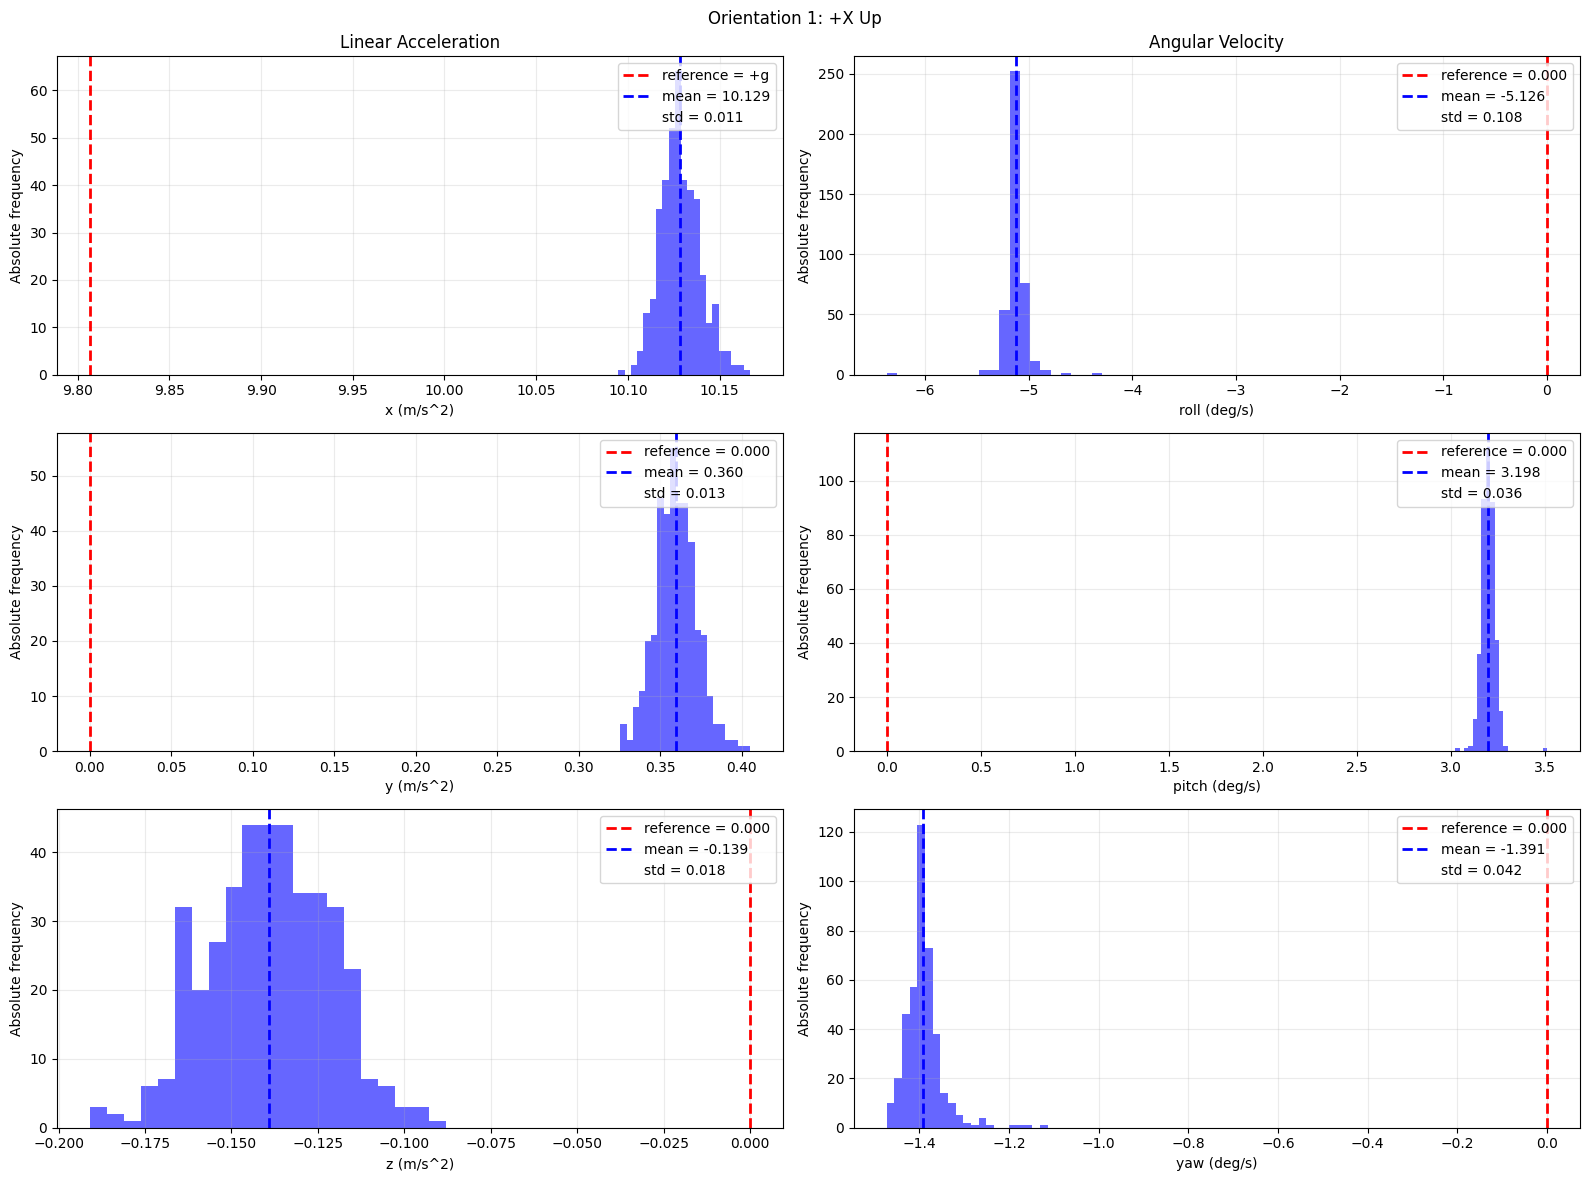

In [ ]:
plotOrientationHistograms(
    sixFaceStationaryCaptures[0],
    title="Orientation 1: +X Up",
    accelReferences=accelReferencesSixFace[0],
)

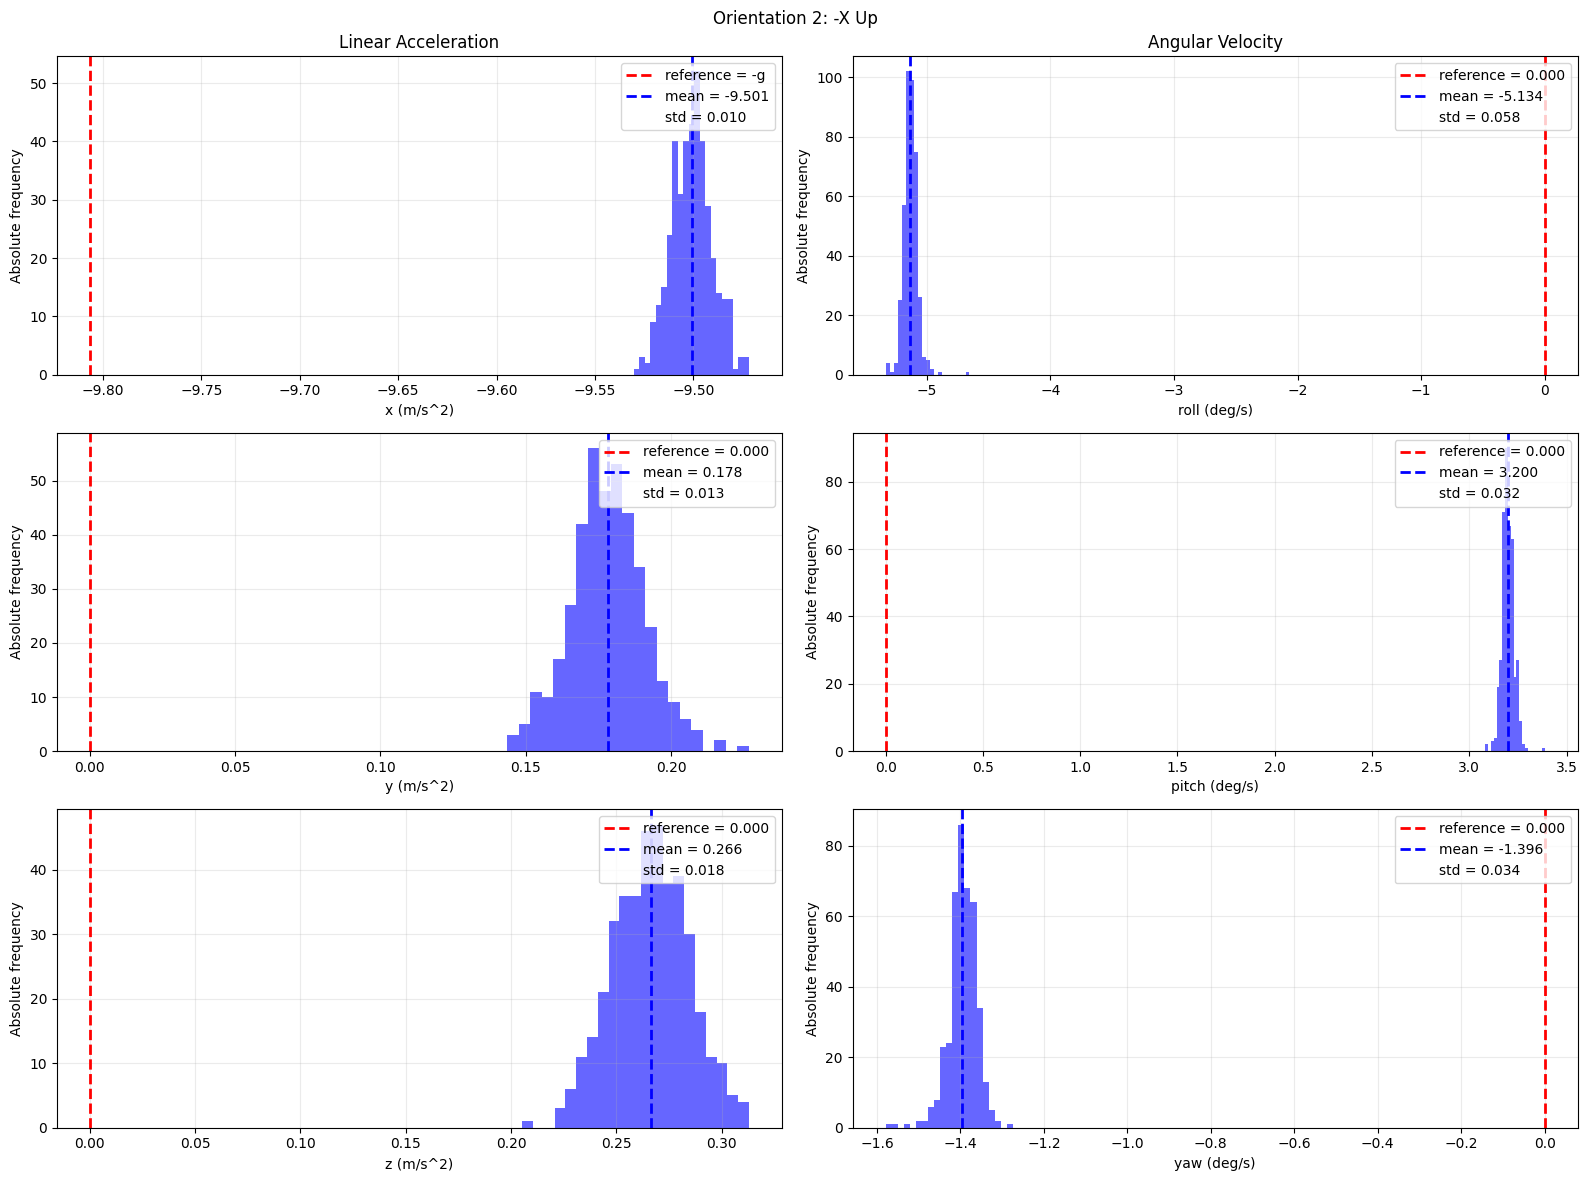

In [ ]:
plotOrientationHistograms(
    sixFaceStationaryCaptures[1],
    title="Orientation 2: -X Up",
    accelReferences=accelReferencesSixFace[1],
)

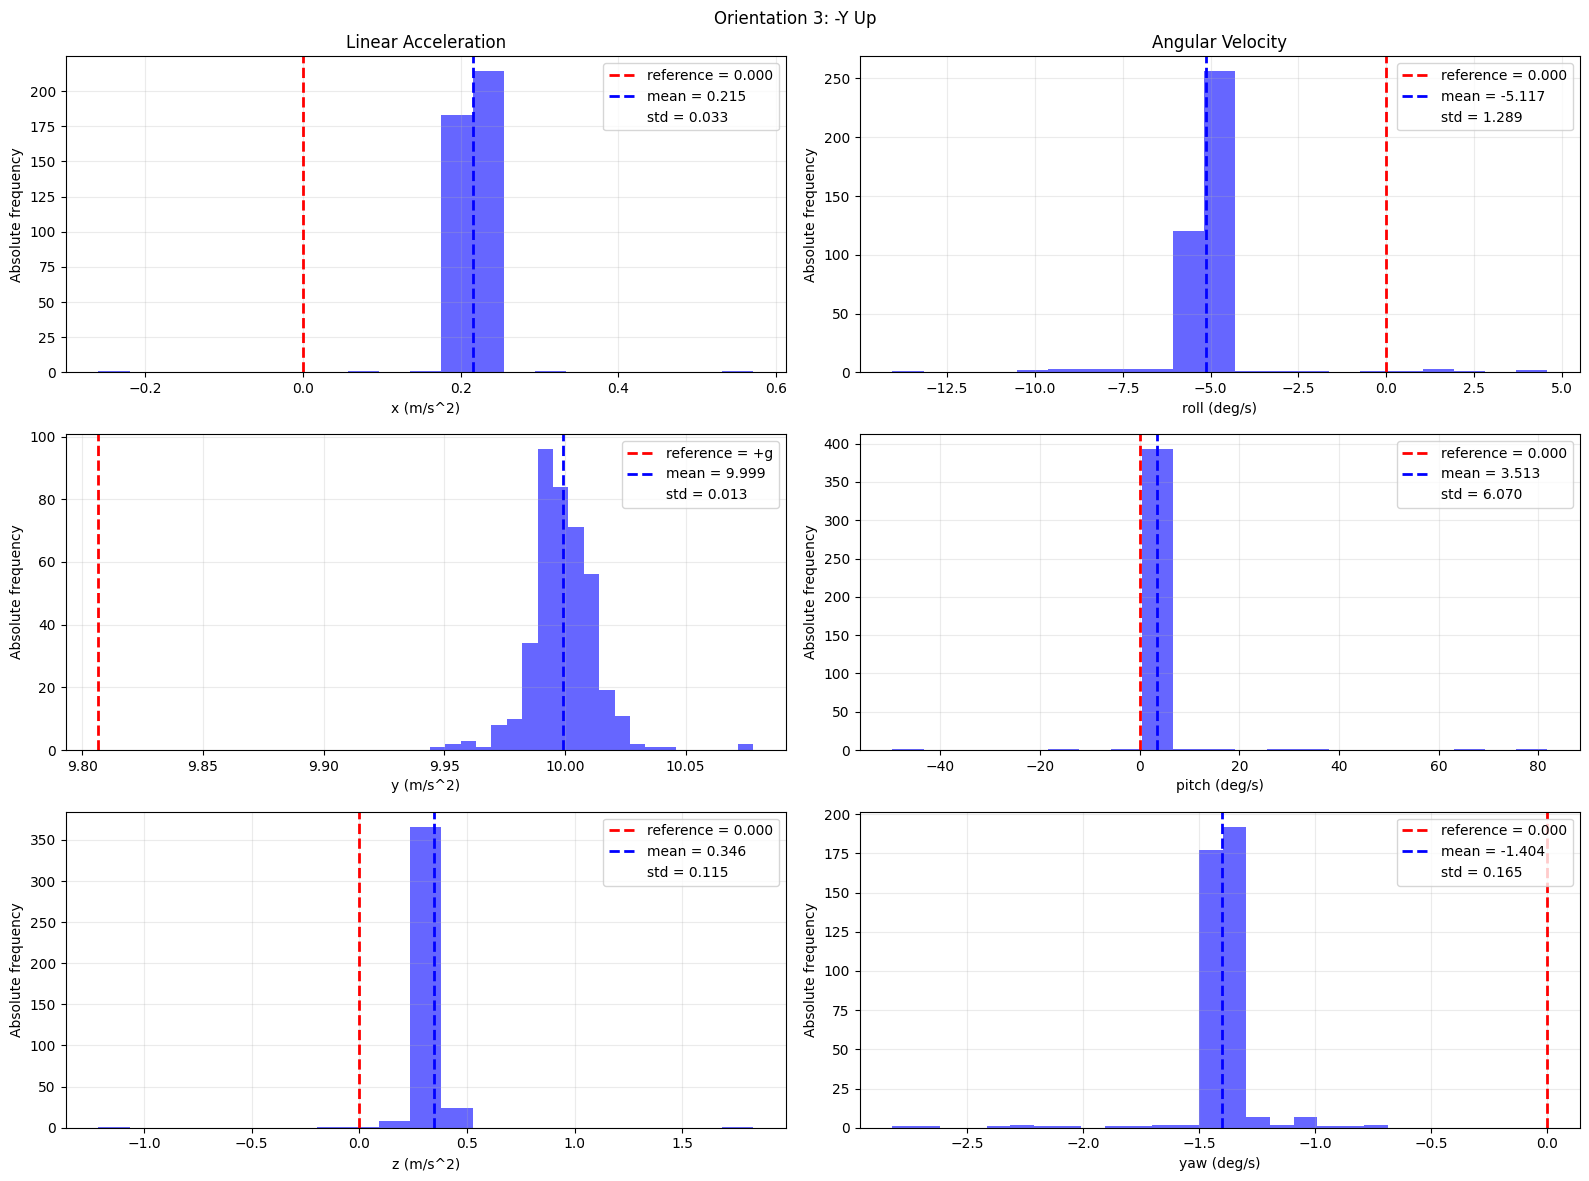

In [ ]:
plotOrientationHistograms(
    sixFaceStationaryCaptures[2],
    title="Orientation 3: +Y Up",
    accelReferences=accelReferencesSixFace[2],
)

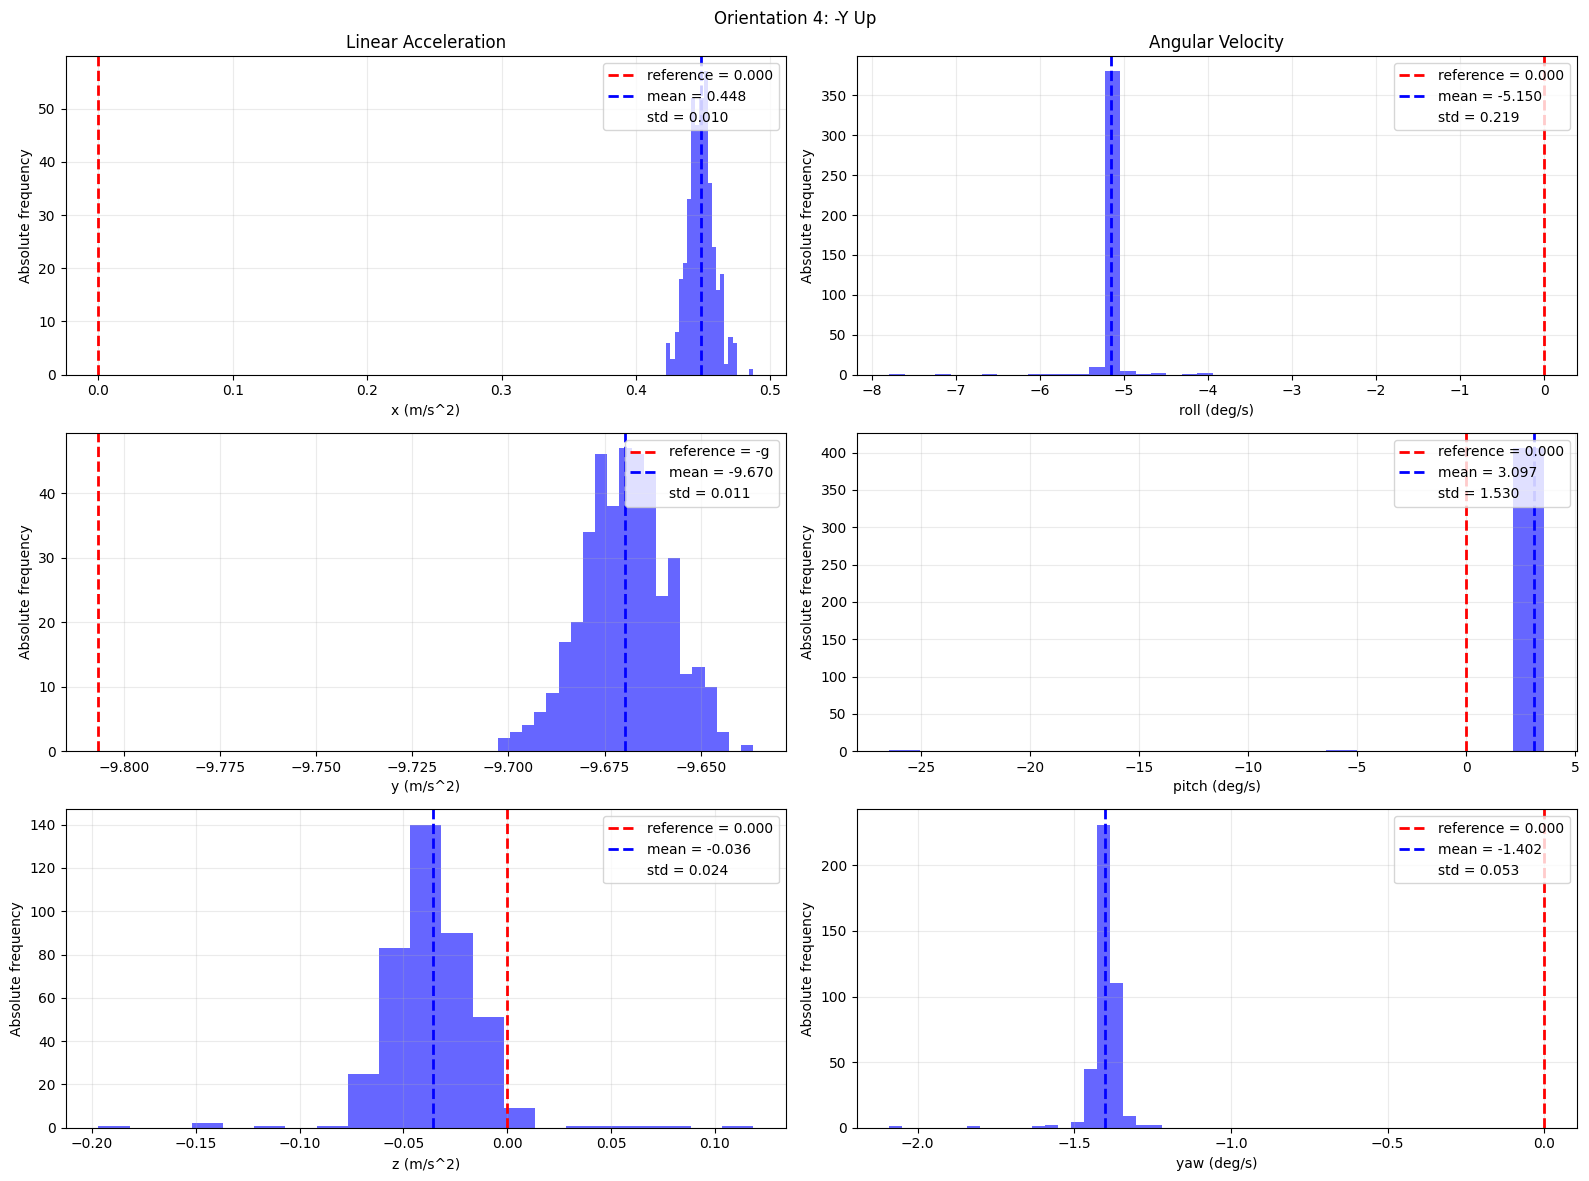

In [ ]:
plotOrientationHistograms(
    sixFaceStationaryCaptures[3],
    title="Orientation 4: -Y Up",
    accelReferences=accelReferencesSixFace[3],
)

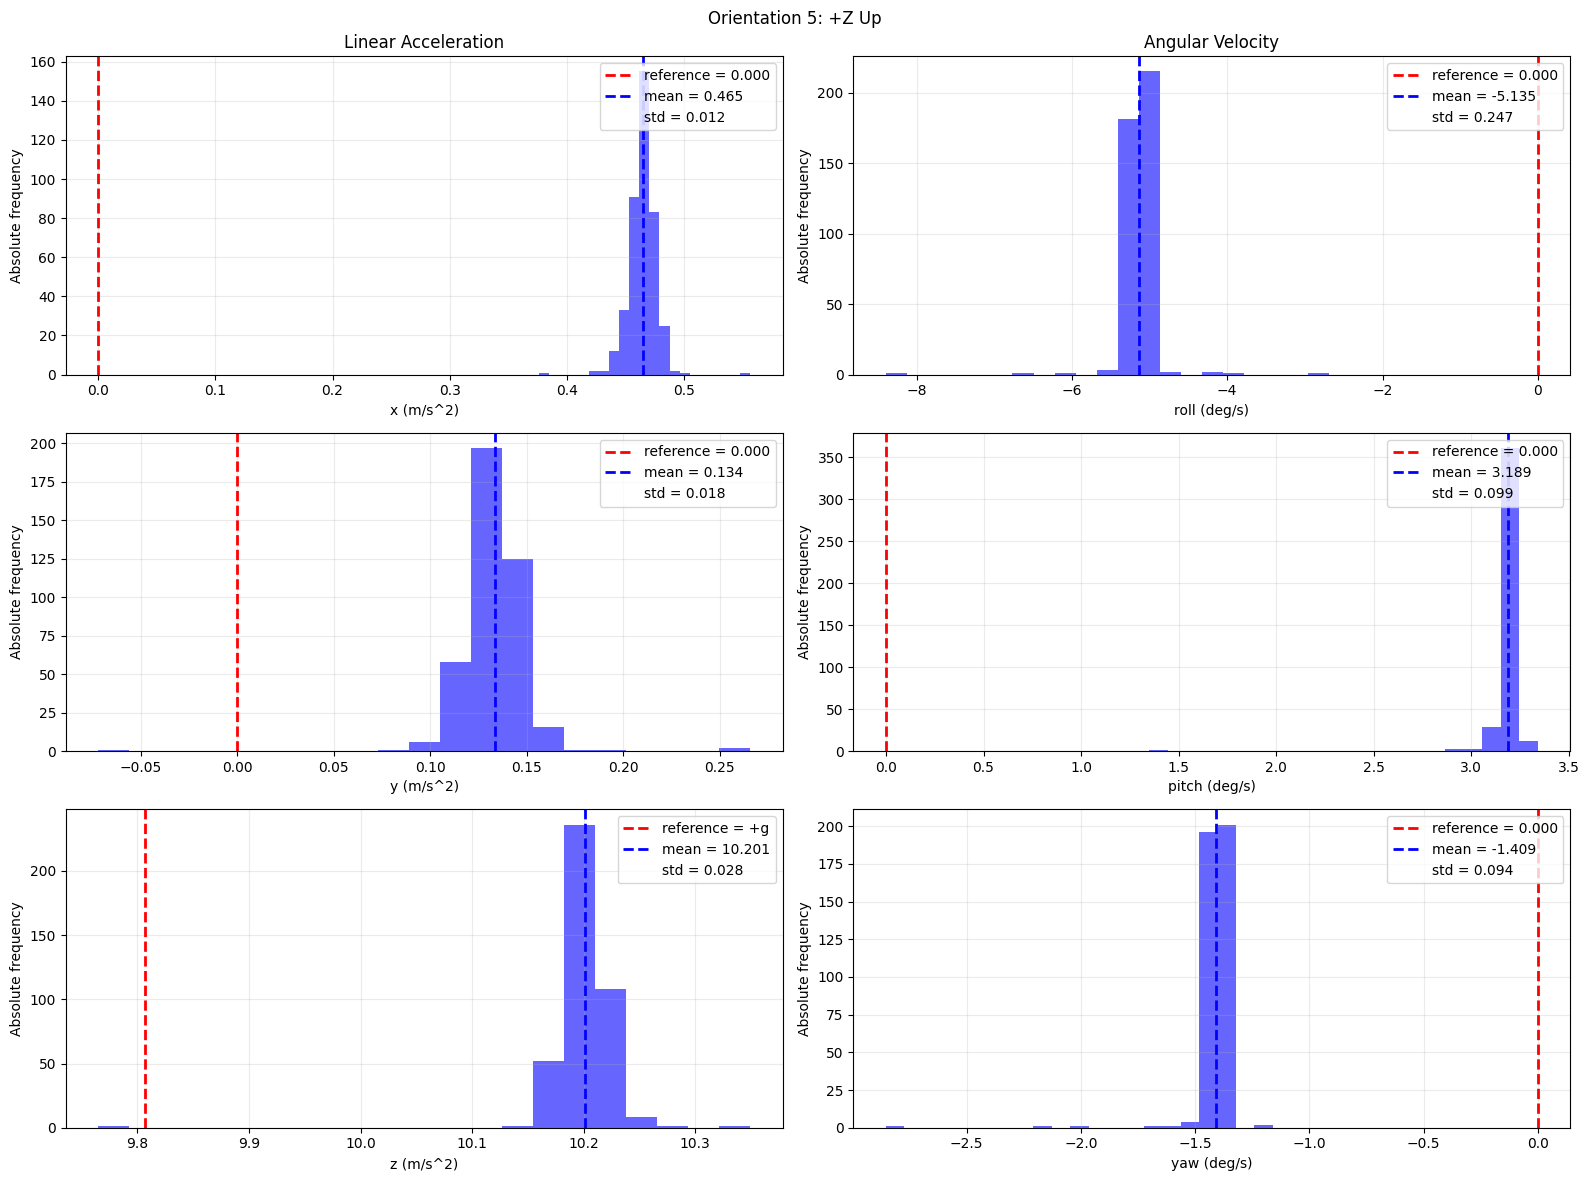

In [ ]:
plotOrientationHistograms(
    sixFaceStationaryCaptures[4],
    title="Orientation 5: +Z Up",
    accelReferences=accelReferencesSixFace[4],
)

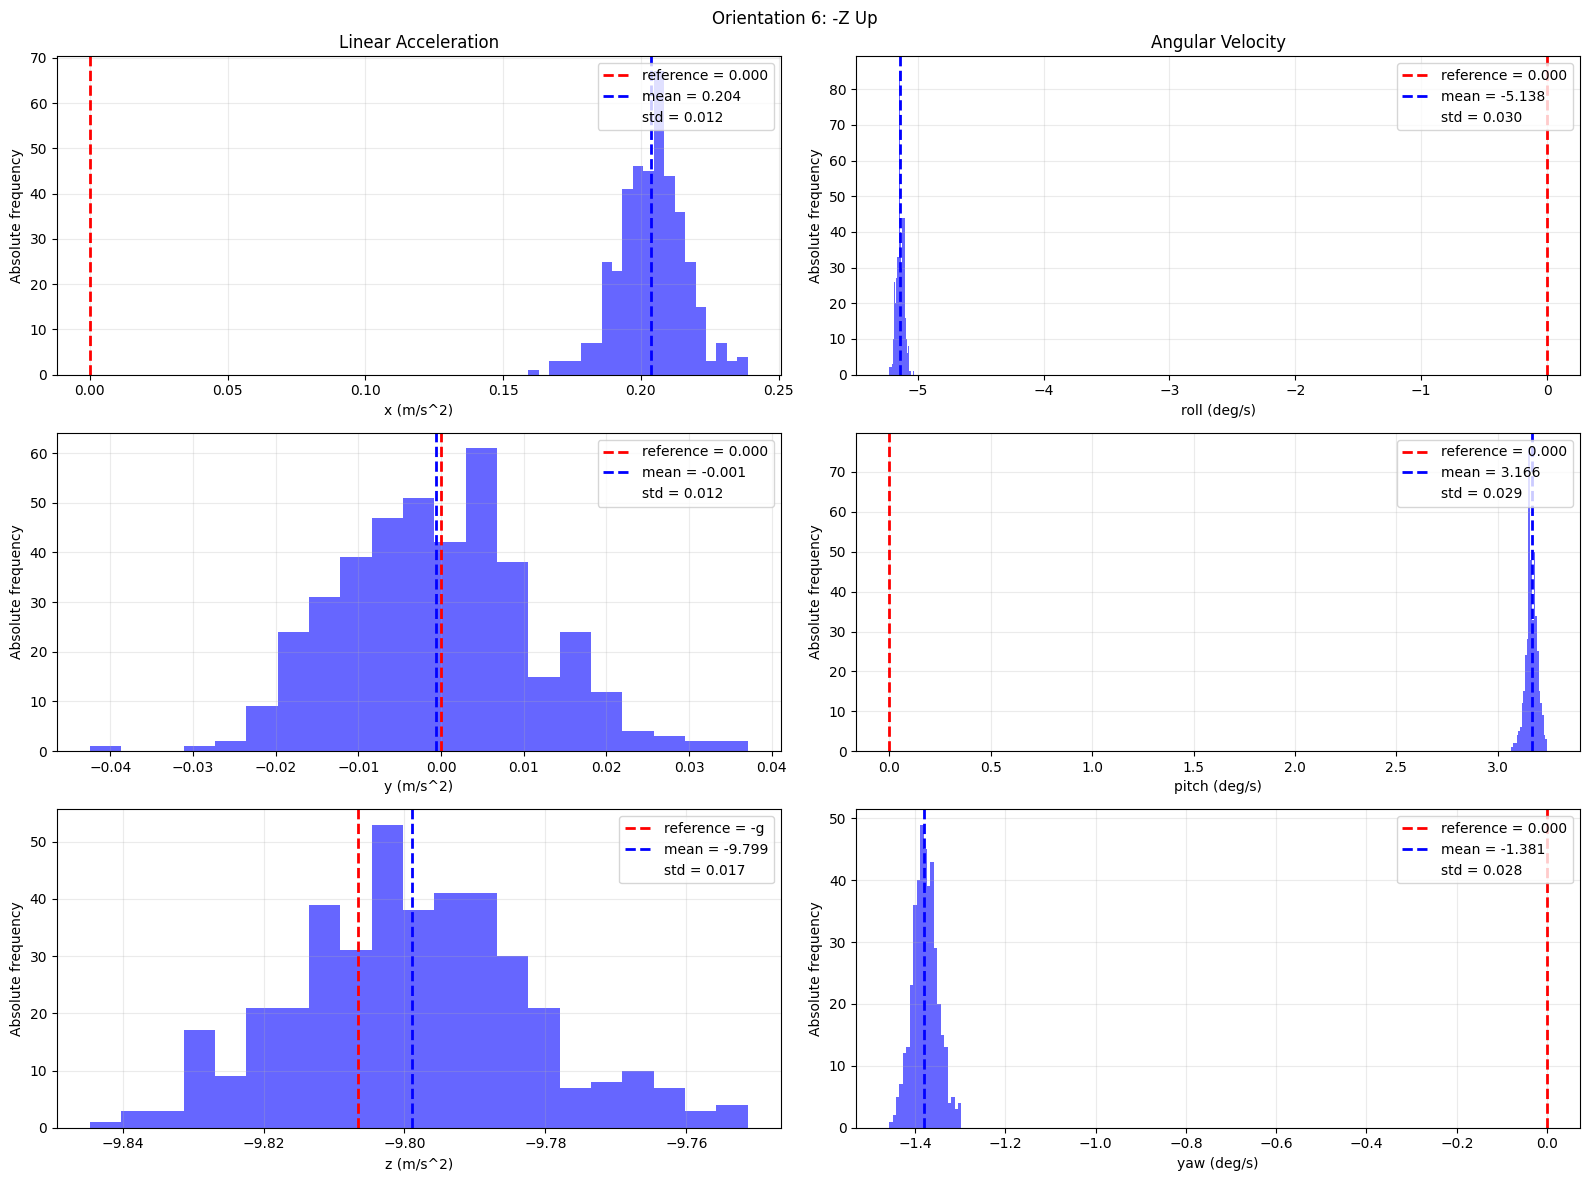

In [ ]:
plotOrientationHistograms(
    sixFaceStationaryCaptures[5],
    title="Orientation 6: -Z Up",
    accelReferences=accelReferencesSixFace[5],
)

### Tilted Orientations (45°)

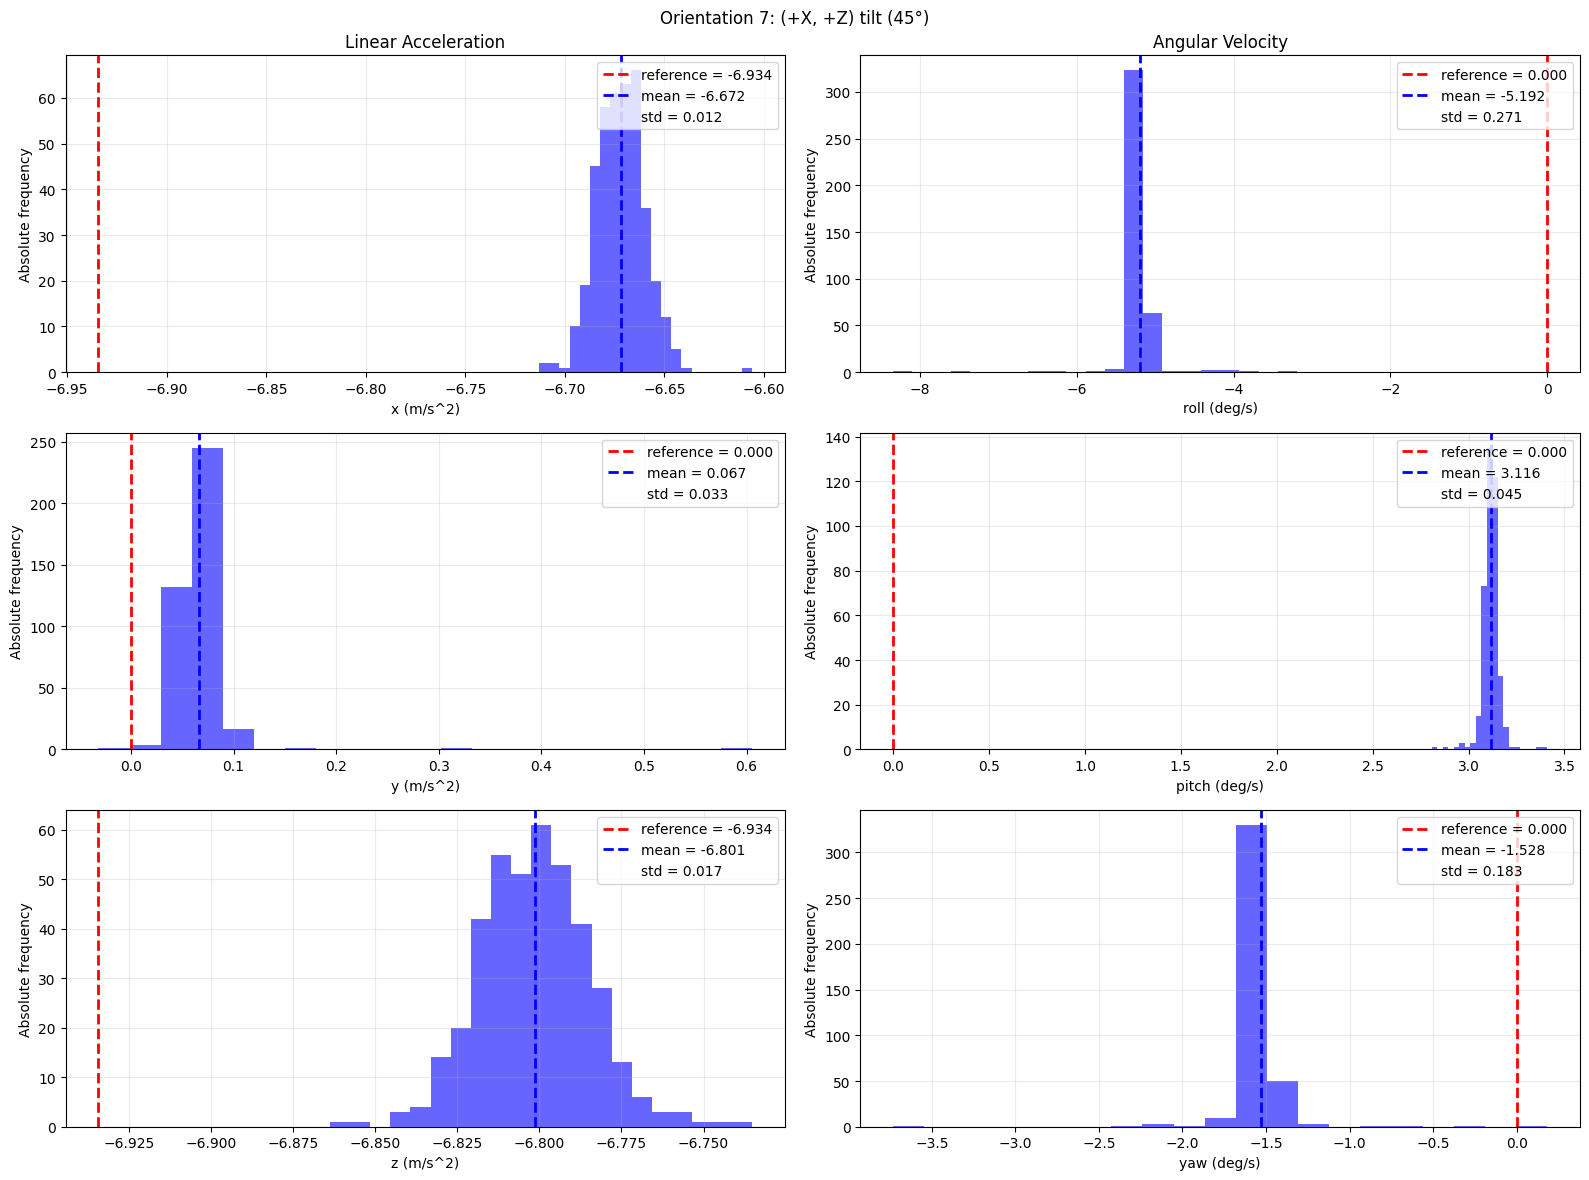

In [ ]:
plotOrientationHistograms(
    tiltedStationaryCaptures[0],
    title="Orientation 7: (+X, +Z) tilt (45°)",
    accelReferences=accelReferencesTilted[0],
)

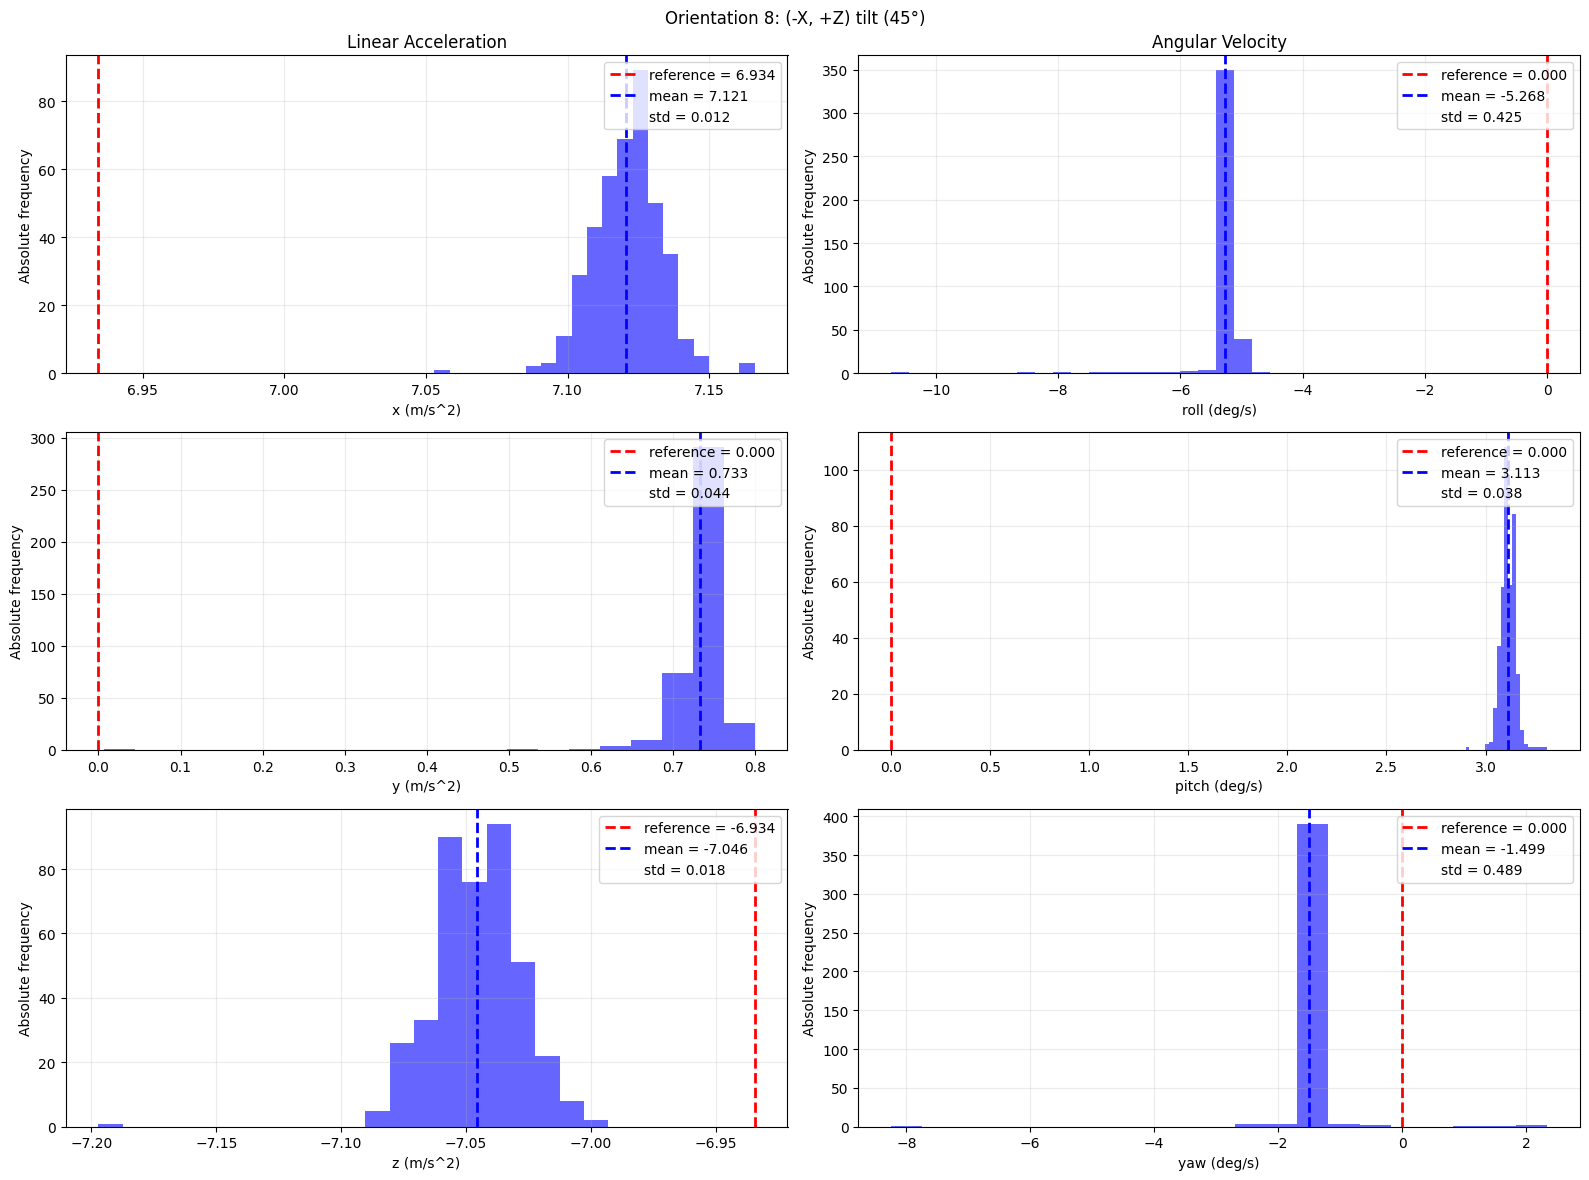

In [ ]:
plotOrientationHistograms(
    tiltedStationaryCaptures[1],
    title="Orientation 8: (-X, +Z) tilt (45°)",
    accelReferences=accelReferencesTilted[1],
)

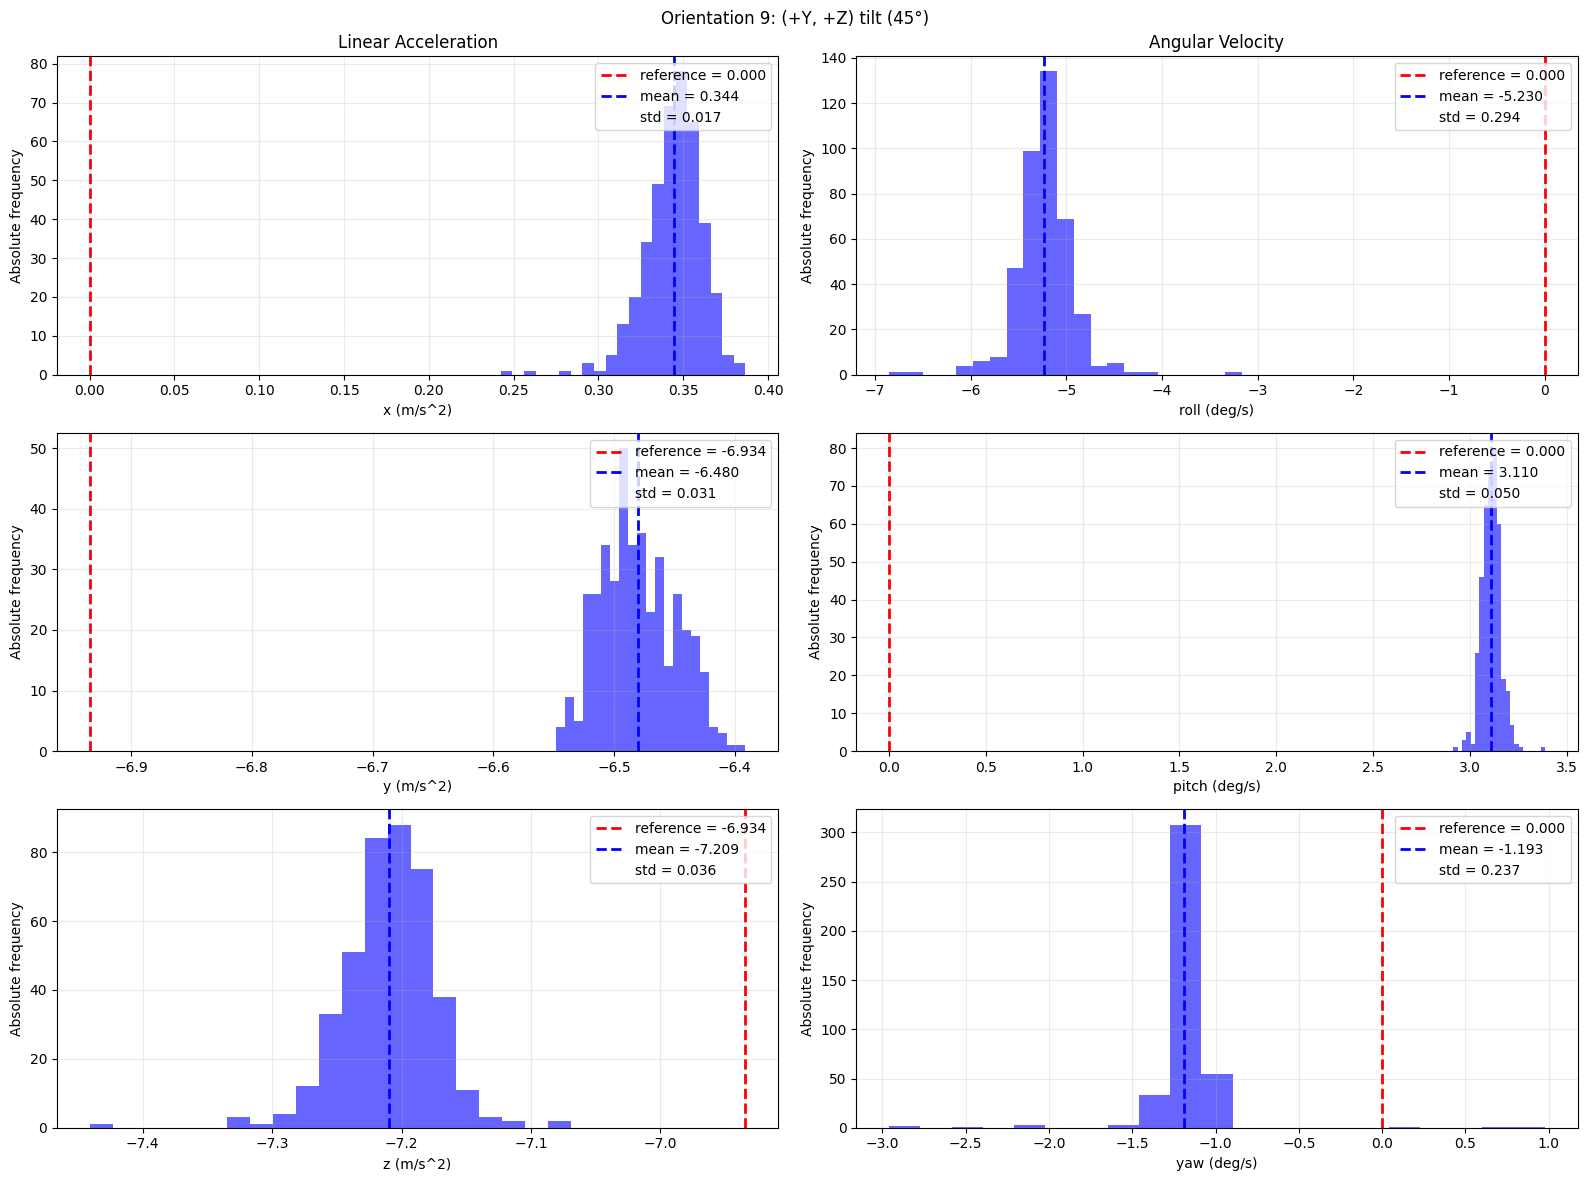

In [ ]:
plotOrientationHistograms(
    tiltedStationaryCaptures[2],
    title="Orientation 9: (+Y, +Z) tilt (45°)",
    accelReferences=accelReferencesTilted[2],
)

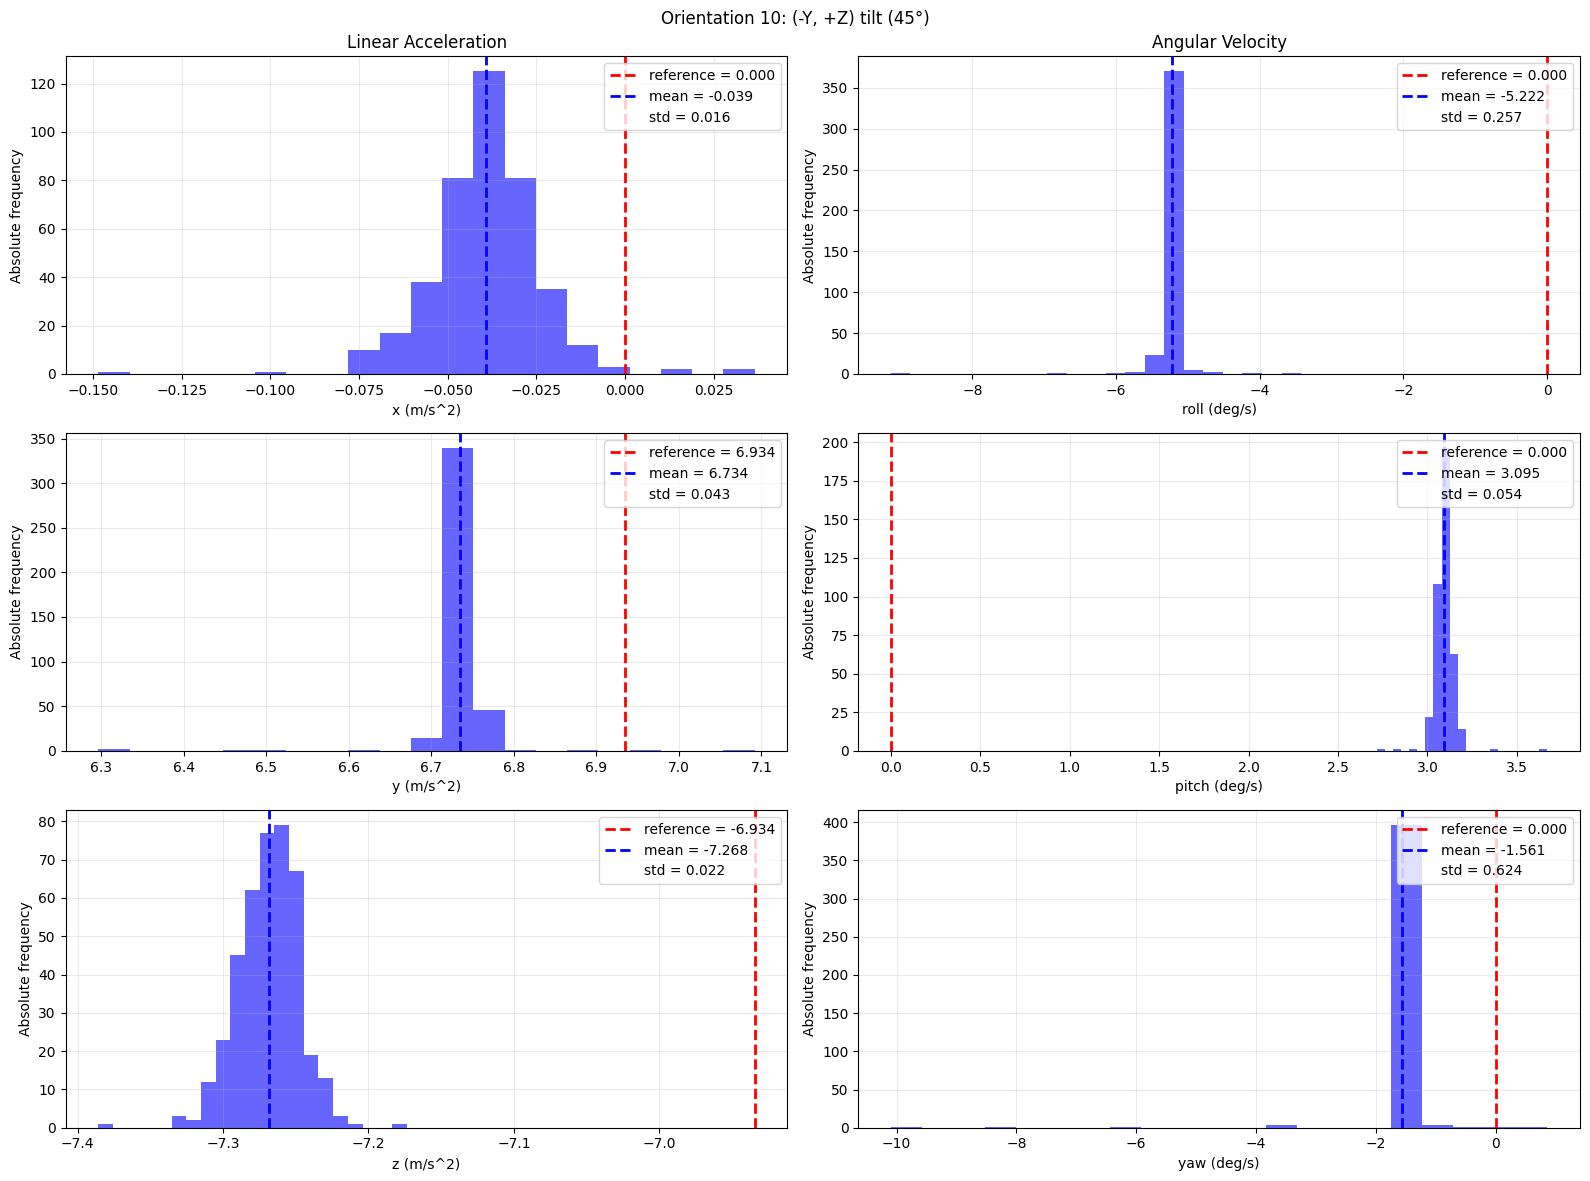

In [ ]:
plotOrientationHistograms(
    tiltedStationaryCaptures[3],
    title="Orientation 10: (-Y, +Z) tilt (45°)",
    accelReferences=accelReferencesTilted[3],
)

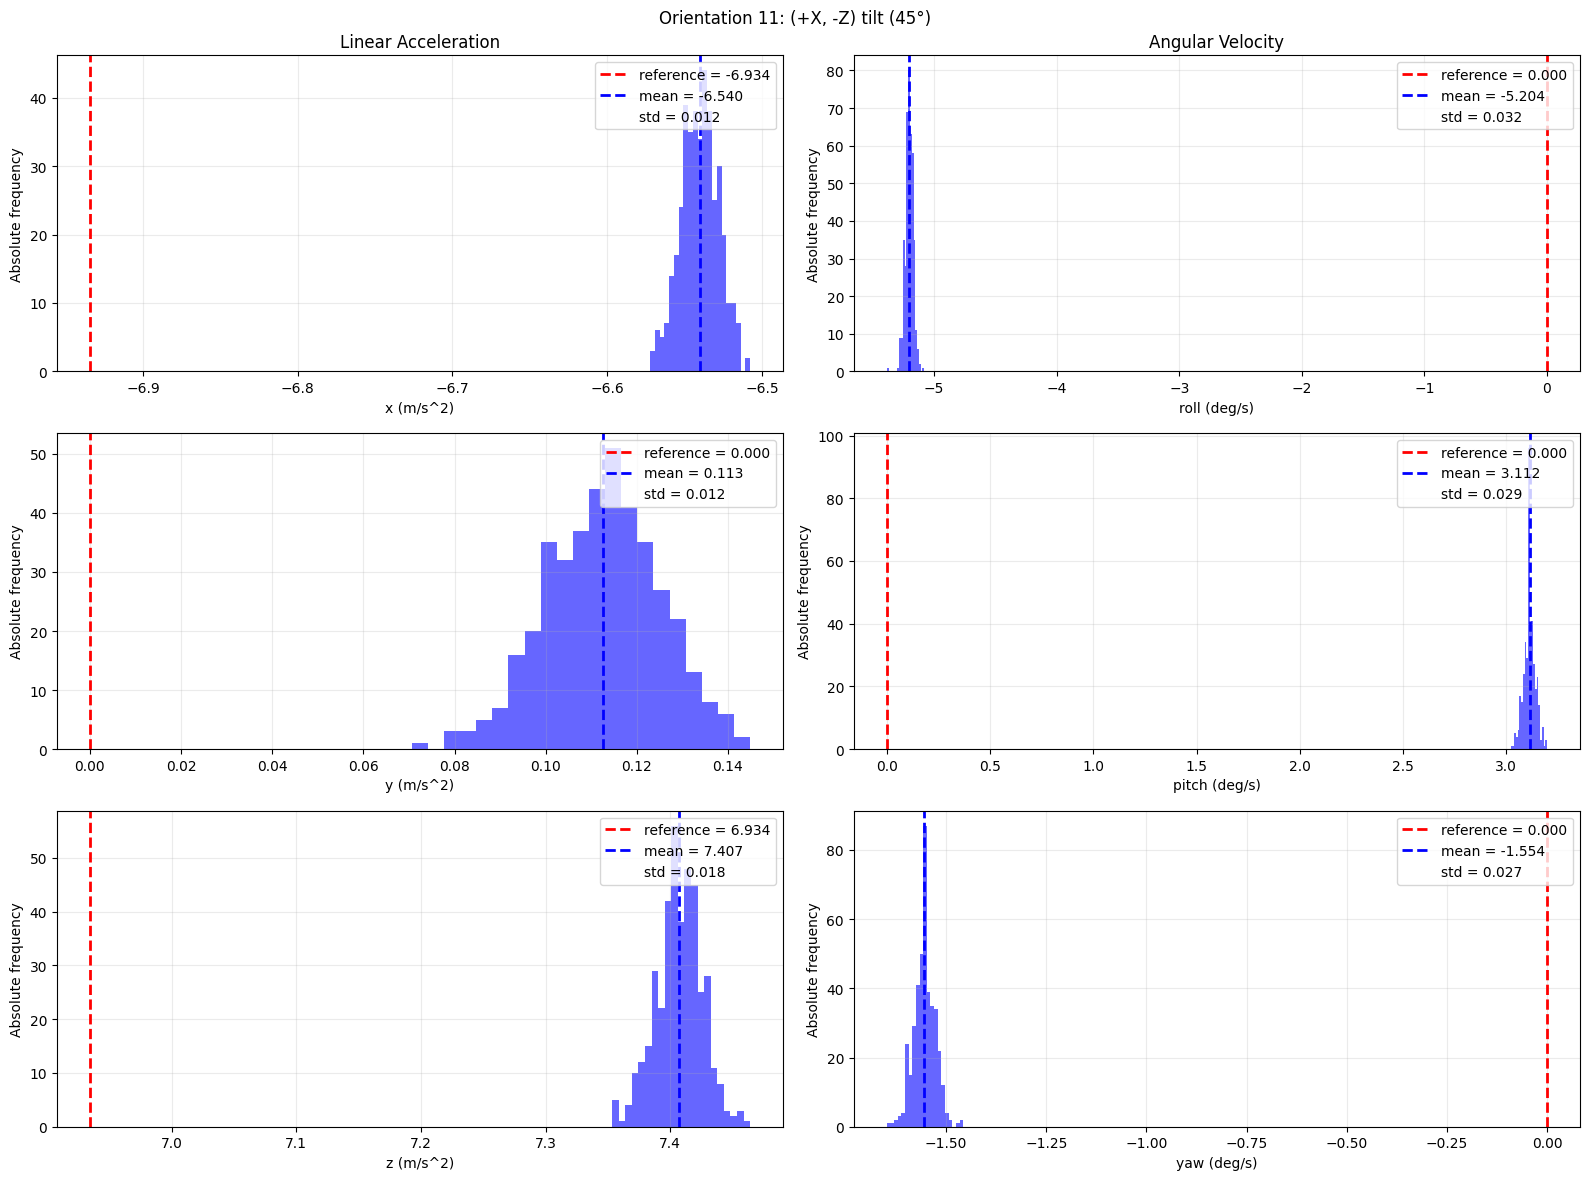

In [ ]:
plotOrientationHistograms(
    tiltedStationaryCaptures[4],
    title="Orientation 11: (+X, -Z) tilt (45°)",
    accelReferences=accelReferencesTilted[4],
)

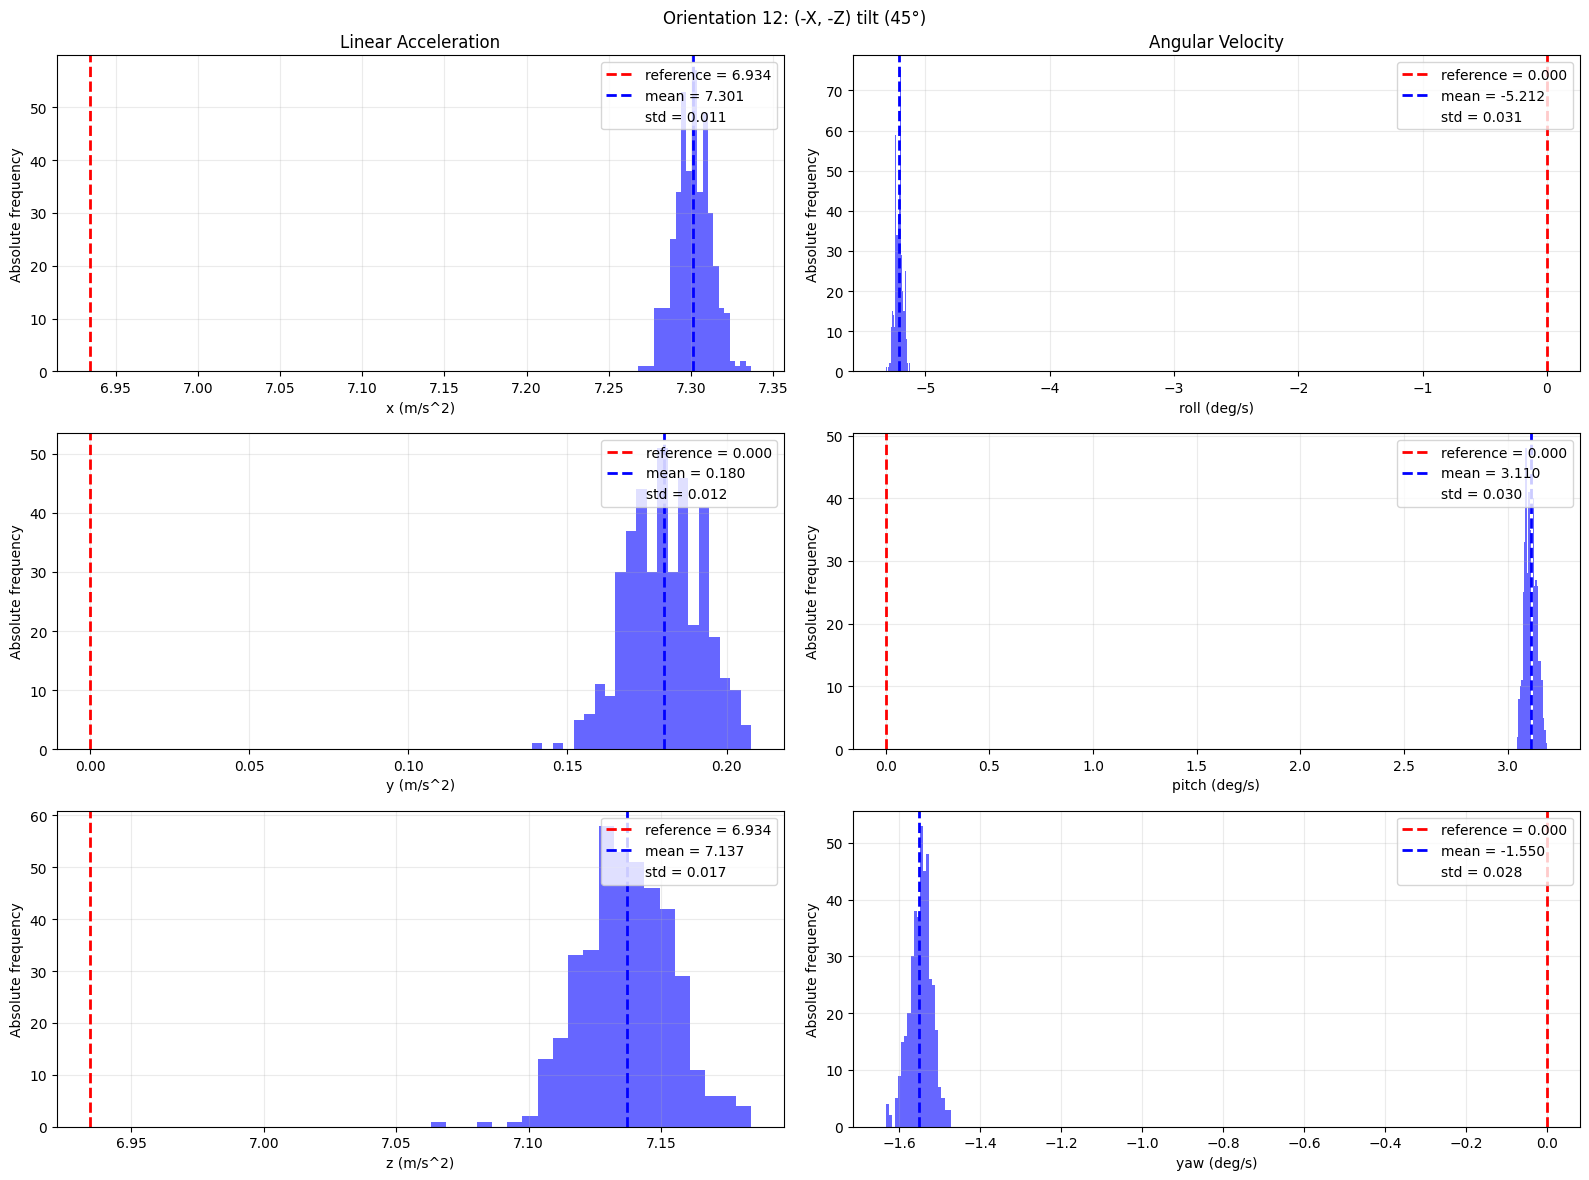

In [ ]:
plotOrientationHistograms(
    tiltedStationaryCaptures[5],
    title="Orientation 12: (-X, -Z) tilt (45°)",
    accelReferences=accelReferencesTilted[5],
)

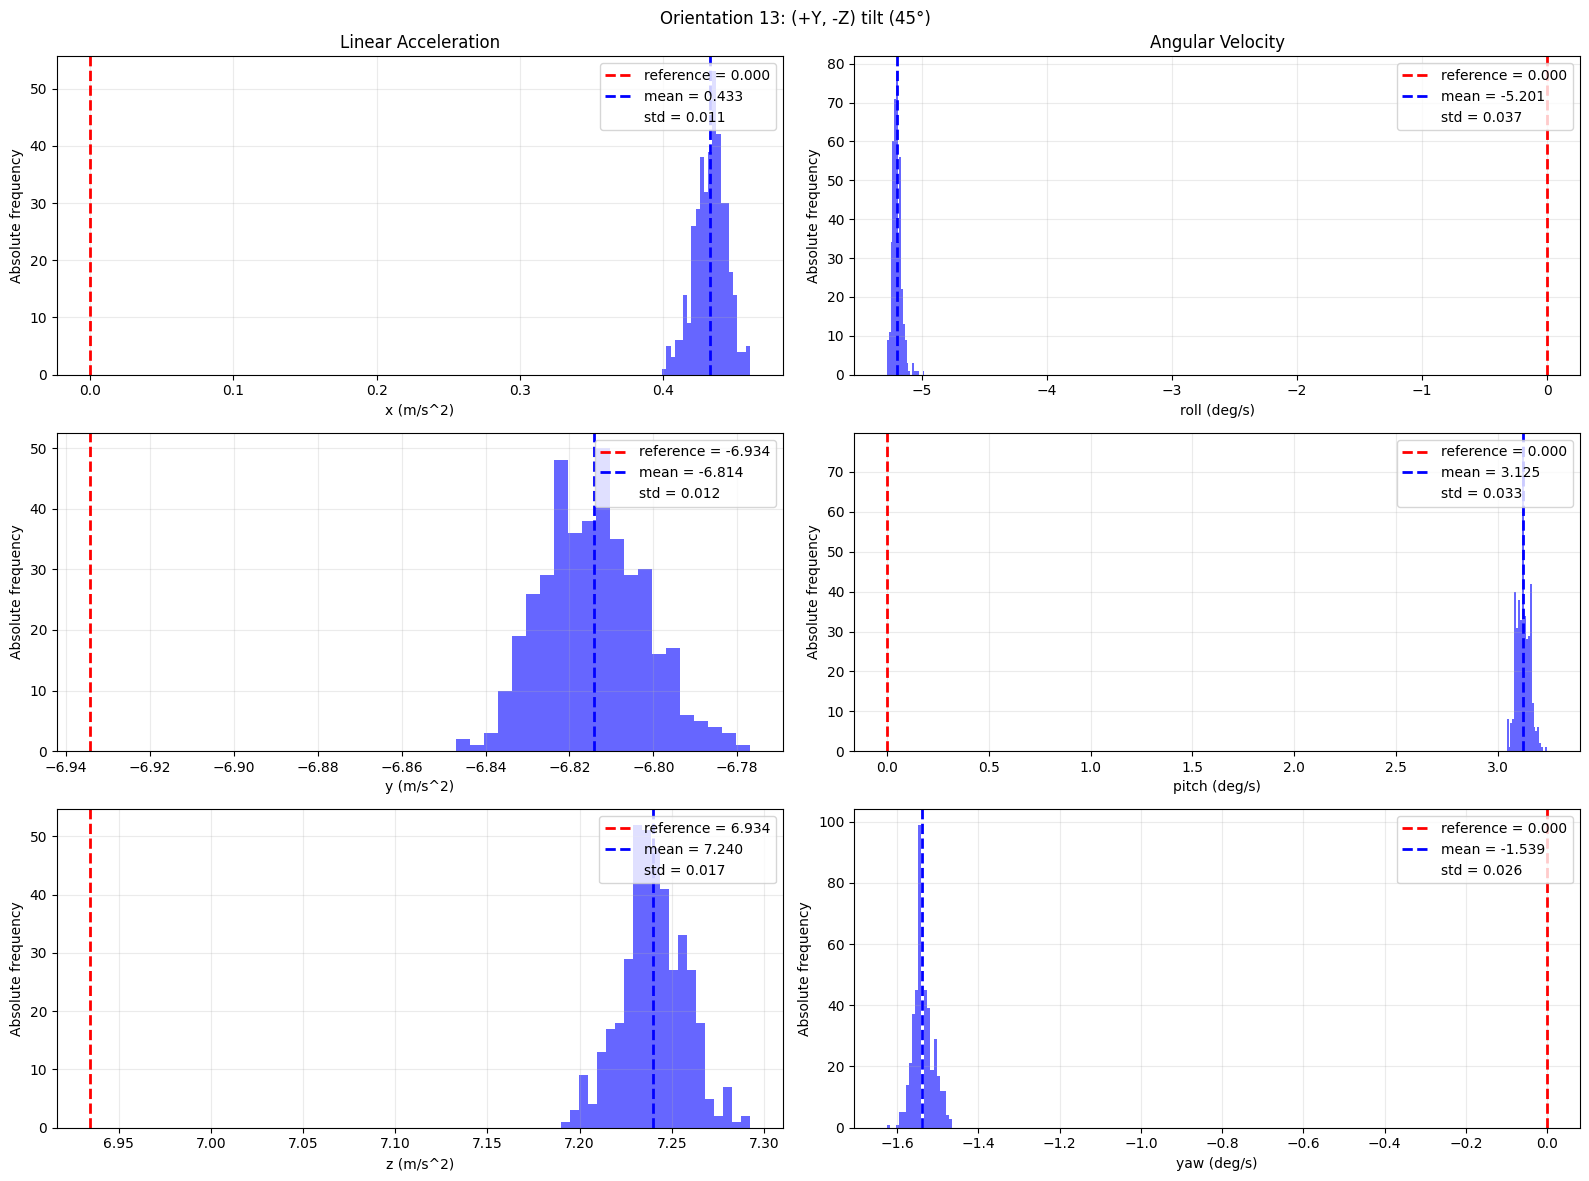

In [ ]:
plotOrientationHistograms(
    tiltedStationaryCaptures[6],
    title="Orientation 13: (+Y, -Z) tilt (45°)",
    accelReferences=accelReferencesTilted[6],
)

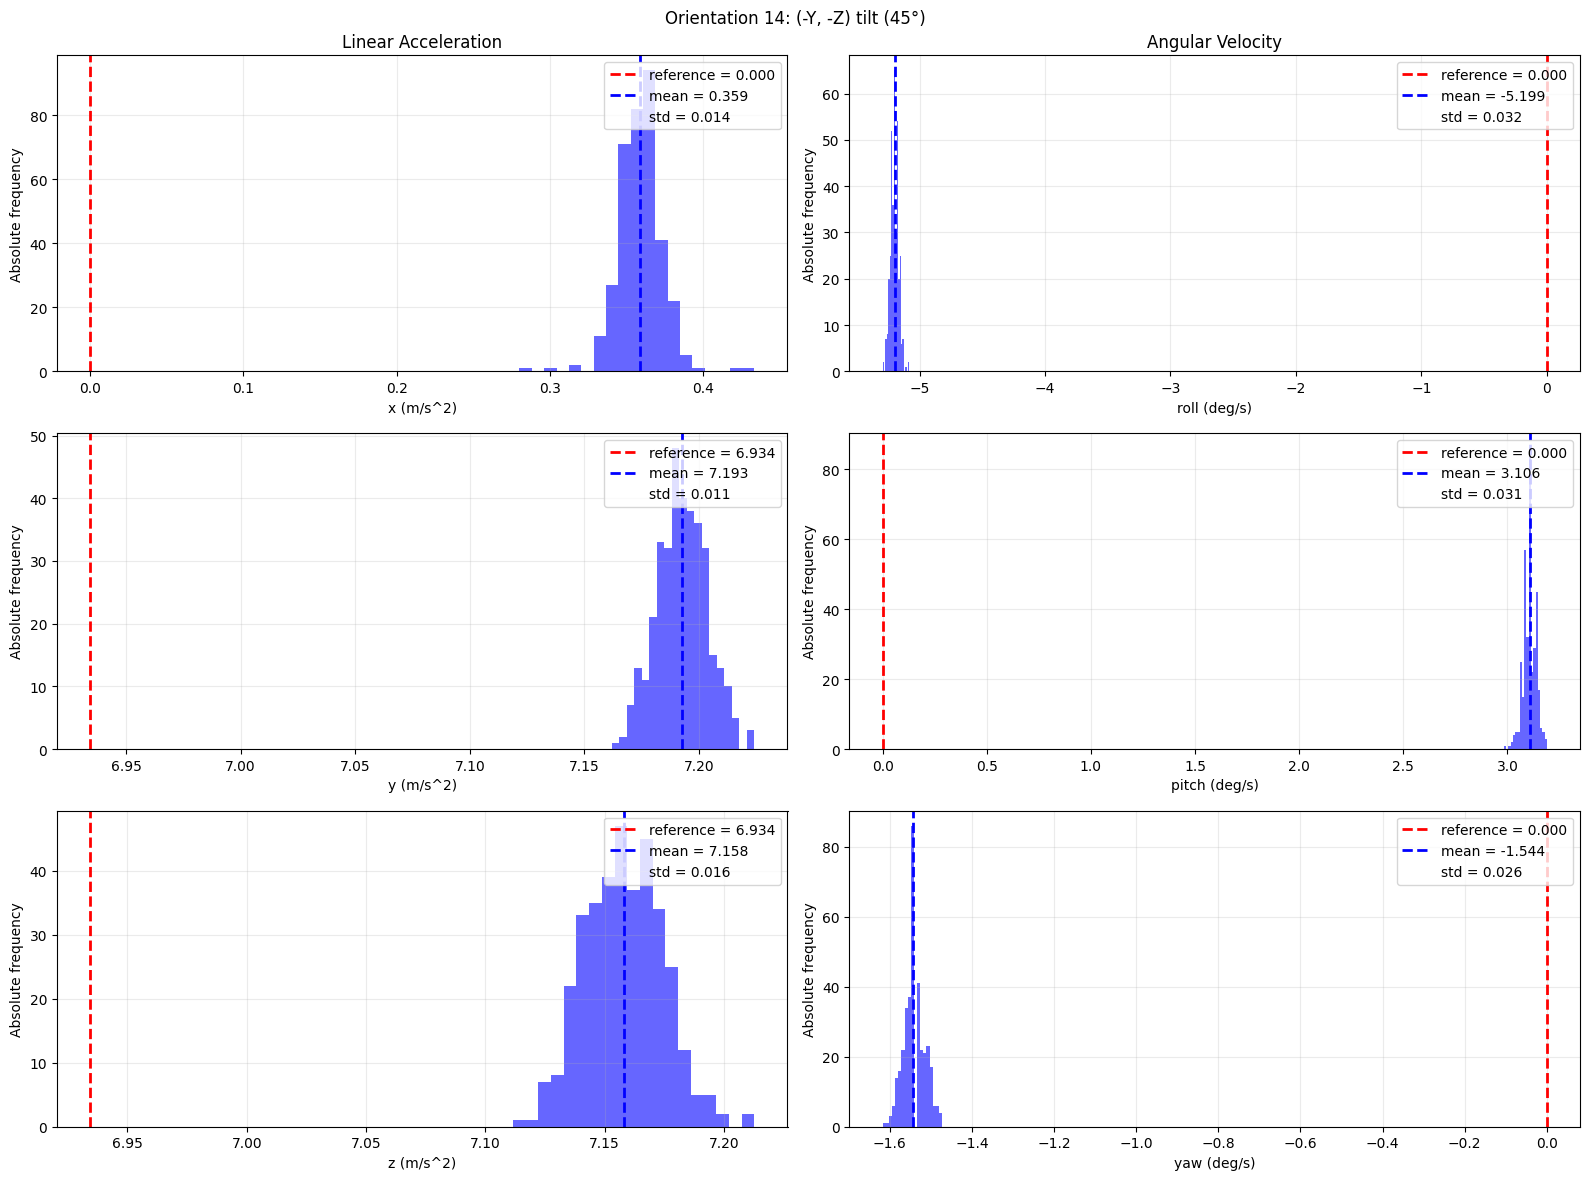

In [ ]:
plotOrientationHistograms(
    tiltedStationaryCaptures[7],
    title="Orientation 14: (-Y, -Z) tilt (45°)",
    accelReferences=accelReferencesTilted[7],
)